In [2]:
import os
import pandas as pd
from pyvi import ViTokenizer
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [3]:
INPUT = '/Users/nguyenducthien/Downloads/Code/Visual Studio Code/training/data/news_vnexpress'

In [4]:
header = "%-20s%-30s" % ("Số lượng văn bản", "Nhãn")
print(header)
print("---------------------------------------------")
n = 0
for label in os.listdir(INPUT):
    label_path = os.path.join(INPUT,label)
    if(os.path.isdir(label_path)):
        n += len(os.listdir(label_path))
        entry = "%-20d%-30s" % (len(os.listdir(label_path)),label)
        print(entry)
print('Tổng số văn bản:',n)

Số lượng văn bản    Nhãn                          
---------------------------------------------
120                 doi-song                      
54                  du-lich                       
59                  phap-luat                     
173                 the-thao                      
59                  thoi-su                       
162                 suc-khoe                      
201                 giai-tri                      
105                 giao-duc                      
262                 kinh-doanh                    
144                 khoa-hoc                      
Tổng số văn bản: 1339


In [5]:
data_train = load_files(container_path=INPUT,encoding='utf-8')
dir(data_train)

['DESCR', 'data', 'filenames', 'target', 'target_names']

In [6]:
header = "%-6s%-10s" % ("ID", "Nhãn")
print(header)
print("---------------------------------------------")
for i in range(len(data_train.target_names)):
    entry = "%-6s%-10s" % (i,data_train.target_names[i])
    print(entry)

ID    Nhãn      
---------------------------------------------
0     doi-song  
1     du-lich   
2     giai-tri  
3     giao-duc  
4     khoa-hoc  
5     kinh-doanh
6     phap-luat 
7     suc-khoe  
8     the-thao  
9     thoi-su   


TfidfTransformer nhận tham số truyền vào là 1 ma trận đếm (matrix) chứ không phải dạng văn bản còn CountVectorizer() nhận tham số truyền vào là list các string. Do vậy khi fit ta có thể truyền vào list các string là data_train.data (có thể kiểm tra = type()) thì bản chất Pipeline là các steps và nó sẽ xử lý theo các bước ta liệu kê; vec sẽ chuyển list các str -> ma trận đếm và ma trận đếm và đầu vào cho TfidfTransformer

In [7]:
with open('data/vietnamese-stopwords.txt',encoding='utf-8') as f:
    stopwords = f.readlines()
for i in range(len(stopwords)):
    stopwords[i] = stopwords[i].strip().replace(' ','_')
print('Tổng số lượng từ dừng:',len(stopwords))
print('Danh sách 10 từ dừng đầu tiên (từ không mang ý nghĩa phân loại): ',stopwords[0:10])
print()
bow = CountVectorizer(stop_words=stopwords)
tf = Pipeline(steps=[
    ('vec',bow),
    ('idf',TfidfTransformer())
])
data_preprocessed = tf.fit_transform(data_train.data)
print('5 từ đầu tiên trong từ điển:')
i = 0
for k,v in bow.vocabulary_.items():
    i += 1
    print(i, ": ",(k,v))
    if i > 5: break
print()
print('Số chiều của dữ liệu:',data_preprocessed.shape)
print('Số từ trong từ điển:',len(bow.vocabulary_))

Tổng số lượng từ dừng: 2063
Danh sách 10 từ dừng đầu tiên (từ không mang ý nghĩa phân loại):  ['a_lô', 'a_ha', 'ai', 'ai_ai', 'ai_nấy', 'ai_đó', 'alô', 'amen', 'anh', 'anh_ấy']

5 từ đầu tiên trong từ điển:
1 :  ('mời', 7462)
2 :  ('độc', 12711)
3 :  ('giả', 4378)
4 :  ('câu', 3084)
5 :  ('ảnh', 12756)
6 :  ('trung', 11017)

Số chiều của dữ liệu: (1339, 12796)
Số từ trong từ điển: 12796


Vì sao cross_validation và train_test_split là 2 phương pháp lấy mẫu mà ta lại import nó trong thư viện model_selection (lựa chọn mô hình)? Đơn giản vì đây là 2 phương pháp lấy mẫu của chúng ta để đánh giá mô hình của mình có hoạt động tốt hay không

Ta đánh giá thông qua .score đối với mô hình hoặc có 1 mảng score trả về nếu dùng cross_validation và mục đích của chúng ta là chọn mô hình có "điểm" - là thang đo hiệu năng của một mô hình học máy, là cao nhất. Ta không được có tư duy là 1 phương pháp lấy mẫu sẽ tương ứng một mô hình. Mô hình của ta chỉ được huấn luyện trên 1 tập dữ liệu train nào đó thường được xét bởi random sampling (train_test_split) còn cross validation hay stratified, k-fold,... chỉ là công cụ để đánh giá hiệu năng

Một trong các hàm dùng để trả về điểm là cross_validation_score với tham số cv = n sẽ trả về 1 array n chiều của score mô hình đó. Mỗi phần tử thứ i của array là score của mô hình khi tập data được chia thành n phần (0 -> n-1) mà phần thứ i là data[i] được sử dụng làm test_set còn n-1 phần còn lại là training_set. Lưu ý rằng thứ nhất ta truyền vào cả data_set chứ không phải data_train vì mục đích là đánh giá mô hình vì tập test_set của ta không phải được xác định riêng mà xác định theo cross_validation và thứ hai đây là 1 đánh giá chứ không phải huấn luyện. Do vậy ta vẫn cần huấn luyện mô hình bằng tập data_train riêng thường xác định bởi train_test_split

GridSearchCV() là một đối tượng cũng thuộc model_selection nhưng nó mang mục đích là lựa chọn mô hình chứ không đơn thuần là đánh giá hiệu năng. Thang đo hiệu năng có thể là accuracy hoặc nhiều độ đo khác, và ta sẽ cần train model trêm tập dữ liệu và đo hiệu năng trên tập validation_test đó. trainning_data, validation_set và test_set cần rời nhau nhưng việc chia train_test_split hay gì đó sẽ chưa tổng quát hóa được kết quả. Thay vào đó ta dùng cross_validation cho tập data_train. Cụ thể ta chia sẵn 2 tập data_train và data_set còn tập data_train ta sẽ truyền vào GridSearchCV, nhờ cross_validation mà mỗi lượt i (i = 0 -> n-1 với cv = n) thì data_train sẽ được chia thành training_set để huấn luyện model và đo hiệu năng trên validation_set (data_train[i]) và độ đo hiệu năng cuối sẽ được tính trung bình. Hơn nữa, GridSearchCV sẽ lưu lại model tốt nhất ở best_estimator_. GridSearchCV() không phải một mô hình mà là một lớp bao của nó (có thể hiểu nôm na như vậy). Việc dùng hàm fit() sẽ thực hiện việc huấn luyện và đánh giá hiệu năng của từng mô hình

    Cơ chế Refit: Sau khi tìm được best_params_, nó tự động lấy bộ tham số đó huấn luyện lại trên toàn bộ X_train bạn đưa vào ban đầu. Đây chính là cái model nằm trong best_estimator_.

    GridSearchCV: Sau khi chạy, thuộc tính cv_results_ của nó chứa một Dictionary cực kỳ chi tiết, bao gồm: thời gian huấn luyện từng lượt, điểm số trung bình, độ lệch chuẩn của điểm số...

### Chia dữ liệu thành 2 phần train_data và test_data
- train_data chiếm 80 % dữ liệu 
- test_data chiếm 20 % dữ liệu 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(data_preprocessed,data_train.target,test_size=0.2)
print('Dữ liệu training = ',X_train.shape,y_train.shape)
print('Dữ liệu testing = ',X_test.shape, y_test.shape)

Dữ liệu training =  (1071, 12796) (1071,)
Dữ liệu testing =  (268, 12796) (268,)


#### - Hiển thị ra id, tên nhãn của 5 văn bản đầu tiên trong tập train. 

In [9]:
map = {}
for i in range(len(data_train.target_names)):
    map[i] = data_train.target_names[i]  
for i in range(5):
    print(f'Văn bản thứ {i} có ID là {y_train[i]} và nhãn {map[y_train[i]]}')

Văn bản thứ 0 có ID là 3 và nhãn giao-duc
Văn bản thứ 1 có ID là 8 và nhãn the-thao
Văn bản thứ 2 có ID là 2 và nhãn giai-tri
Văn bản thứ 3 có ID là 0 và nhãn doi-song
Văn bản thứ 4 có ID là 5 và nhãn kinh-doanh


In [10]:
print("- Training ...")
print('-Train size = ',X_train.shape)
svm = SVC(kernel='linear',C=1.0)
svm.fit(X_train,y_train)
print('- model - train complete')

- Training ...
-Train size =  (1071, 12796)
- model - train complete


## Đánh giá SVM trên tập test_data
Độ đo đánh giá: 
> accuracy = tổng số văn bản dự đoán đúng  / tổng số văn bản có trong tập test_data  

metric là 1 gói, dịch ra là số liệu, dùng để đưa ra các số liệu và đánh giá về độ chính xác của mô hình, tức sai lệnh giữa dự đoán y_predict và y_test. Một vài các hàm nổi bật như accuracy_score, precision_score, recall_score, f1_score và confusion_matrix cho bài toán phân loại còn bài toán hồi quy thì có mean_absolute_error, mean_squared_error và r2_error. Hơn nữa classification_report là công cụ hữu ích để tổng hợp các thông tin trên cho bài toán phân loại
>accuracy_score là số dự đoán đúng /tổng số dự đoán của ta

>precision_score cho 1 lớp i là số dự đoán đúng lớp i (nằm trên đường chéo ma trận nhầm lẫn, hàng i cột i)/ số dự đoán là lớp i (tổng cột i). Tùy thuộc vào tham số average = 'micro', 'macro' hay weighted mà precision_score sẽ được tính khác

>recall_score cho 1 lớp i là số dự đoán đúng lớp i (nằm trên đường chéo ma trận nhầm lẫn, hàng i cột i)/ số mẫu thực sự là lớp i (tổng hàng i). Tùy thuộc vào tham số average = 'micro', 'macro' hay weighted mà recall_score sẽ được tính khác

In [11]:
print('- Testing ...')
y_predict = svm.predict(X_test)
print("- Acc = ", accuracy_score(y_test,y_predict))

- Testing ...
- Acc =  0.9253731343283582


### Sử dụng model đã được huấn luyện để phán đoán 1 văn bản mới 
- Dữ liệu mới đến ở dạng dữ liệu thô => cần tiền xử lý dữ liệu về dạng dữ_liệu_ma_trận
- Phán đoán bằng hàm model.predict(dữ_liệu_ma_trận) 

In [12]:
news = ["Công_phượng ghi bàn cho đội_tuyển Việt_nam"]
preprocessed_news = tf.transform(news)
print(preprocessed_news, end='\n\n')
label = svm.predict(preprocessed_news)
print(label,data_train.target_names[label[0]])


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (1, 12796)>
  Coords	Values
  (0, 2045)	0.7485869990170734
  (0, 4284)	0.663036578857164

[8] the-thao


Cách đầu tiên lâu hơn hẳn do ta dùng cross_validation thay vì vòng lặp, hơn nữa 2 cách đại diện cho 2 trường phái khác nhau: GridSearch() là chọn tham số để trung accuracy_score trên tập validation_test (thuộc train_data) là nhỏ nhất còn cách vòng lặp là ta ngăn không cho mô hình học test_data và sử dụng accuracy trên tập đó làm thước đo đánh giá mô hình

In [13]:
gs = GridSearchCV(estimator=svm,param_grid=[
    {'C':[0.1,1.0,5.0,10.0],'kernel':['linear', 'poly', 'rbf', 'sigmoid']}],cv = 5,scoring='accuracy')
gs.fit(X_train,y_train)

,estimator,SVC(kernel='linear')
,param_grid,"[{'C': [0.1, 1.0, ...], 'kernel': ['linear', 'poly', ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,5.0


In [14]:
print(gs.best_params_)

{'C': 5.0, 'kernel': 'linear'}


In [15]:
ker = ['linear', 'poly', 'rbf', 'sigmoid']
c = [0.1, 1.0, 5.0, 10.0]
score = -1
for i in ker:
    for j in c:
        svm = SVC(kernel = i, C = j)
        svm.fit(X_train, y_train)
        y_predict = svm.predict(X_test)
        if(score < accuracy_score(y_test,y_predict)):
            score = accuracy_score(y_test,y_predict)
            kernel_best = i
            C_best = j
print(f'kernel = {kernel_best} còn C = {C_best}')

kernel = linear còn C = 5.0


## Phân loại sổ viết tay

Lần này ta làm quen với cách xử lý 1 dataset mới đó là dataset có sẵn trên sklearn(). Ta đã tìm hiểu xử lý text từ file trên máy bằng việc dùng load_files chuyển về kiểu bunch, xử lý file csv bằng cách đưa về DataFrame. Lần này ta dùng dữ liệu có sẵn

In [16]:
import matplotlib.pyplot as plt
from sklearn import datasets, svm, metrics

Cú pháp import datasets, svm , metrics giúp ta truy cập được mọi hàm của thư viện đó nhưng điều này không tối ưu lắm vì ta load quá nhiều thứ mà có thể không dùng đến.

    Đối với những hàm mà ta không hiểu hoặc cần documnetation, chỉ việc help() hoặc không () mà thêm dấu ? vào sau

In [60]:
digits = datasets.load_digits()
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [18]:
plt.subplot?

Signature: plt.subplot(*args, **kwargs) -> 'Axes'
Docstring:
Add an Axes to the current figure or retrieve an existing Axes.

This is a wrapper of `.Figure.add_subplot` which provides additional
behavior when working with the implicit API (see the notes section).

Call signatures::

   subplot(nrows, ncols, index, **kwargs)
   subplot(pos, **kwargs)
   subplot(**kwargs)
   subplot(ax)

Parameters
----------
*args : int, (int, int, *index*), or `.SubplotSpec`, default: (1, 1, 1)
    The position of the subplot described by one of

    - Three integers (*nrows*, *ncols*, *index*). The subplot will take the
      *index* position on a grid with *nrows* rows and *ncols* columns.
      *index* starts at 1 in the upper left corner and increases to the
      right. *index* can also be a two-tuple specifying the (*first*,
      *last*) indices (1-based, and including *last*) of the subplot, e.g.,
      ``fig.add_subplot(3, 1, (1, 2))`` makes a subplot that spans the
      upper 2/3 of the figu

In [19]:
plt.colormaps()

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

Trước tiên chúng ta cần thử in ra các ảnh bằng imshow(), tương tự có thể đọc bằng imread() nhưng chỉ cho 1 ảnh mà thôi thường là 1 ma trận 2 chiều hoặc 3 chiều. Nhưng sau khi show thì ta cần chú ý rằng ảnh của ta thường có 8*8 = 64 bit ảnh thôi nên để nó hiển thị trên nhiều bit hơn cần những bit ảnh trống khác phải mang màu nào đó -> interpolation, thường rõ nét nhất khi là nearest. Hơn nữa khi xử lý ta cần đưa ma trận về dạng 1 vector -> dùng reshape()

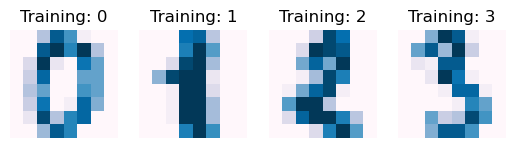

In [20]:
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.axis('off')
    plt.imshow(digits.images[i],cmap=plt.cm.PuBu,interpolation='nearest')
    plt.title('Training: %i' % digits.target[i])

Chúng ta có thể làm phẳng 3D matrix về 2D matrix thông qua câu lệnh reshape() và tham số truyền vào là tuple(n_rows, n_columns) nhưng ta cũng có thuộc tính hỗ trợ điều đó.

In [21]:
data = digits.images.reshape((len(digits.images),-1))
data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [22]:
data = digits.data
target = digits.target
X_train, X_test, y_train, y_test = train_test_split(data,target,test_size=0.2)
print("Dữ liệu training = ", X_train.shape, y_train.shape)
print("Dữ liệu testing = ", X_test.shape, y_test.shape)

Dữ liệu training =  (1437, 64) (1437,)
Dữ liệu testing =  (360, 64) (360,)


In [23]:
print("- Training ...")
print('- Train size = ', X_train.shape)
svm = SVC(kernel='linear',C=1.0)
svm.fit(X_train,y_train)
print("- model - train complete")
print("- Testing ...")
y_predict = svm.predict(X_test)
print('- Acc = ',accuracy_score(y_test,y_predict))

- Training ...
- Train size =  (1437, 64)
- model - train complete
- Testing ...
- Acc =  0.9833333333333333


## Bây giờ ta tiến hành đọc 1 file các ảnh 

In [27]:
import os
import numpy as np

In [45]:
INPUT = 'data/digits_data'
images = []
labels = []

Vấn đề ta phải dùng câu lệnh isdir và ispath như vậy là do Macos tự tạo thêm file .DS_Store mỗi khi ta bấm mở file đó trong finder. Nhưng ta biết rằng file ẩn có tên (label) bắt đầu bằng dấu '.' nên có thể loại đi bằng cách sau

In [61]:
for label in os.listdir(INPUT):
    if label.startswith('.'): continue
    label_path = os.path.join(INPUT,label)
    for image_name in os.listdir(label_path):
        if image_name.startswith('.'): continue
        image_path = os.path.join(label_path,image_name)
        image = plt.imread(image_path)
        images.append(image)
        labels.append(label)
img = np.array(images)
img.shape

(50800, 128, 128)

Bây giờ thì images là 1 ndarray 2 chiều, tiếp ta cần đưa về dạng vector. Lưu ý đây không phải kiểu dữ liệu có sẵn trên datasets() nên không có cú pháp .data mà phải dùng reshape() tức cần chuyển array về ndarray

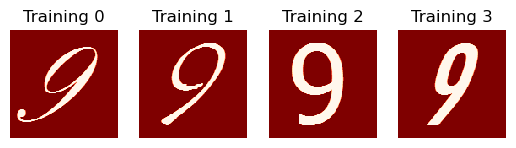

In [69]:
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.axis('off')
    plt.imshow(images[i],cmap=plt.cm.OrRd,interpolation='nearest')
    plt.title(f'Training {i}')

In [68]:
img = img.reshape((len(img),-1))
img.shape

(50800, 16384)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(img,labels,random_state=42,test_size=0.2)

In [70]:
gs = GridSearchCV(estimator=SVC(),param_grid={
    'kernel': ['linear','poly','rbf','sigmoid'], 
    'C':[0.01, 0.1, 1]},
    scoring='accuracy', cv = 3)
gs.fit(X_train,y_train)
svm = gs.best_estimator_

In [71]:
y_predict = svm.predict(X_test)
accuracy_score(y_test,y_predict)

0.9888888888888889